# Data analysis for NLP tasks

In [10]:
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns
import catppuccin
import numpy as np

import pycountry

sns.set_theme(style="whitegrid")
plt.style.use(catppuccin.PALETTE.latte.identifier)

## Preprosses

In [ ]:
dic_list_langs = {
    "global_mmlu": [
        "de",
        "en",
        "fa",
        "fr",
        "he",
        "ja",
        "ne",
        "pl",
        "si",
        "sn",
        "so",
        "sr",
        "sv",
        "yo",
    ],
    "mmmlu": [
        "ar",
        "bn",
        "de",
        "es",
        "fr",
        "hi",
        "id",
        "it",
        "ja",
        "ko",
        "pt",
        "sw",
        "yo",
        "zh_cn",
    ],
    "xnli": [
        "en",
        "de",
        "ru",
        "fr",
        "zh",
        "es",
        "vi",
        "tr",
        "sw",
        "ar",
        "el",
        "th",
        "bg",
        "hi",
        "ur",
    ],
    "paws-x": ["en", "de", "fr", "zh", "es", "ja", "ko"],
    "xlsum": ["en", "fr", "zh", "es", "vi", "tr"],
    "mkqa": ["en", "de", "ru", "fr", "zh_cn", "es", "ja", "vi", "tr", "th"],
}

In [ ]:
def get_unique_langs(lang_dict):
    return list({lang for langs in lang_dict.values() for lang in langs})


In [ ]:

unique_langs = get_unique_langs(dic_list_langs)
len(unique_langs)

In [ ]:
langs_and_names: dict[str, str] = {}
for lang in unique_langs:
    if lang == "zh_cn":
        langs_and_names[lang] = "Chinese (Simplified)"
    else:
        langs_and_names[lang] = pycountry.languages.get(alpha_2=lang).name
    
        
langs_and_names

ds_langs_and_names = pd.DataFrame(
    {
        "Language Code": list(langs_and_names.keys()),
        "Language Name": list(langs_and_names.values()),
    }
)
#ds_langs_and_names.to_csv("../benchmarks/datasets/languages.csv", index=False)

In [ ]:
path_to_results = "../benchmarks/results-main"

In [ ]:
if not os.path.exists(f"{path_to_results}/accuracy_processed"):
        os.makedirs(f"{path_to_results}/accuracy_processed")


In [ ]:
def process_file(task):
    df = pd.read_csv(f"{path_to_results}/accuracy_{task}.csv", header=None)
    df.columns = ["model", "prompt_type", "lang", "num", "accuracy"]
    # remove rows with num < 250
    #if task == "shareGPT":
    #    df = df[df["num"] >= 50]
    #else:
    #    df = df[df["num"] >= 250]
    # deduplicate
    df = df.drop_duplicates(subset=["model", "prompt_type", "lang", "num"], keep="last")
    df = df.pivot_table(
        index=[
            "num",
            "model",
            "prompt_type",
        ],
        columns="lang",
        values="accuracy",
    )
    df = df.reset_index()
    column_names = [
        "num",
        "model",
        "prompt_type",
    ] + dic_list_langs[task]
    df = df.reindex(columns=column_names)

    # Assume 'column_name' is the column you want to sort and 'specific_order' is the list specifying the order
    df["prompt_type"] = pd.Categorical(
        df["prompt_type"],
        categories=[
            "direct_native",
            "direct",
            "google",
            "google_direct",
            "adamic",
            "adamic_self_trans",
        ],
        ordered=True,
    )
    # df['model'] = pd.Categorical(df['model'], categories=["gpt-3.5-turbo-1106","bigscience/bloomz-7b1","mistralai/Mistral-7B-Instruct-v0.2","meta-llama/Llama-2-13b-chat-hf","TheBloke/Llama-2-70B-Chat-AWQ","ybelkada/Mixtral-8x7B-Instruct-v0.1-AWQ"], ordered=True)
    # Then you can sort the DataFrame by 'column_name'
    df = df.sort_values(
        [
            "num",
            "model",
            "prompt_type",
        ]
    )

    df = df.reset_index(drop=True)
    # save df to csv
    df.to_csv(f"{path_to_results}/accuracy_processed/accuracy_{task}_pivot.csv")

In [ ]:
for task in dic_list_langs.keys():
    process_file(task)

### Preprosses cultural annotations on global_mmlu

In [ ]:
path_to_results = "../benchmarks/results-main"

In [ ]:
dic_list_langs_no_en = {
    "global_mmlu": [
        "de",
        "fa",
        "fr",
        "he",
        "ja",
        "ne",
        "pl",
        "si",
        "sn",
        "so",
        "sr",
        "sv",
        "yo",
    ],
    "mmmlu": [
        "ar",
        "bn",
        "de",
        "es",
        "fr",
        "hi",
        "id",
        "it",
        "ja",
        "ko",
        "pt",
        "sw",
        "yo",
        "zh_cn",
    ],
    "xnli": [
        "de",
        "ru",
        "fr",
        "zh",
        "es",
        "vi",
        "tr",
        "sw",
        "ar",
        "el",
        "th",
        "bg",
        "hi",
        "ur",
    ],
    "paws-x": ["de", "fr", "zh", "es", "ja", "ko"],
    "xlsum": ["fr", "zh", "es", "vi", "tr"],
    "mkqa": ["de", "ru", "fr", "zh_cn", "es", "ja", "vi", "tr", "th"],
}

# to create the accuracy split of high resource and low resource languages, 
# we use Statistics of Common Crawl Monthly Archives https://commoncrawl.github.io/cc-crawl-statistics/plots/languages

# every thing over 1% is deamed a high resource language, everything under 1% is a low resource language.

dic_list_langs_no_en_low_resource = {
   "global_mmlu": [
        "fa",
        "he",
        "ne",
        "si",
        "sn",
        "so",
        "sr",
        "sv",
        "yo",
    ],
    "mmmlu": [
        "ar",
        "bn",
        "hi",
        "ko",
        "sw",
        "yo",
    ],
    "xnli": [
        "sw",
        "ar",
        "el",
        "tr",
        "th",
        "bg",
        "hi",
        "ur",
    ],
    "paws-x": ["ko"],
    "xlsum": ["tr"],
    "mkqa": ["th","tr"],
}

dic_list_langs_no_en_high_resource = {
    "global_mmlu": [
        "de",
        "fr",
        "ja",
        "pl",
    ],
    "mmmlu": [
        "de",
        "es",
        "fr",
        "id",
        "it",
        "ja",
        "pt",
        "zh_cn",
    ],
    "xnli": [
        "de",
        "ru",
        "fr",
        "zh",
        "es",
        "vi",
    ],
    "paws-x": ["de", "fr", "zh", "es", "ja"],
    "xlsum": ["fr", "zh", "es", "vi"],
    "mkqa": ["de", "ru", "fr", "zh_cn", "es", "ja", "vi"],
}

In [ ]:
models_strats = os.listdir(f"{path_to_results}/global_mmlu")
models_strats

In [ ]:
def create_accuracy_for_cultural_annotationed_global_mmlu(list_of_models_strats: list[str]):
    for model_strat in list_of_models_strats:
        model, strat = model_strat.split("_", maxsplit=1)
        langs = os.listdir(f"{path_to_results}/global_mmlu/{model_strat}")
        
        for lang in langs:
            if os.path.isfile(f"{path_to_results}/global_mmlu/{model_strat}/{lang}/summary.csv"):
                df = pd.read_csv(f"{path_to_results}/global_mmlu/{model_strat}/{lang}/summary.csv")
                mean_accuracy = df[df['metadata']=='CS']['check'].mean()
                num_samples = df[df['metadata']=='CS']['check'].count()
                
                with open(f"{path_to_results}/global_mmlu_cultural_accuracy.csv", "a") as f:
                    f.write(f"{model},{strat},{lang},{num_samples},{mean_accuracy}\n")


In [ ]:
create_accuracy_for_cultural_annotationed_global_mmlu(models_strats)

In [ ]:
def process_cultural():
    df = pd.read_csv(f"{path_to_results}/global_mmlu_cultural_accuracy.csv", header=None)
    df.columns = ["model", "prompt_type", "lang", "num", "accuracy"]
    # remove rows with num < 250
    #if task == "shareGPT":
    #    df = df[df["num"] >= 50]
    #else:
    #    df = df[df["num"] >= 250]
    # deduplicate
    df = df.drop_duplicates(subset=["model", "prompt_type", "lang", "num"], keep="last")
    
    # create df with lang and num, drop duplicates, reset index
    df_lang_num = df[["lang", "num"]]
    df_lang_num = df_lang_num.drop_duplicates(subset=["lang", "num"], keep="last")
    df_lang_num.sort_values("lang", inplace=True)
    df_lang_num.set_index("lang", inplace=True)
    
    df = df.pivot_table(
        index=[
            "model",
            "prompt_type",
            
        ],
        columns="lang",
        values="accuracy",
    )
    df = df.reset_index()
    column_names = [
        "model",
        "prompt_type",
    ] + dic_list_langs["global_mmlu"]
    df = df.reindex(columns=column_names)

    # Assume 'column_name' is the column you want to sort and 'specific_order' is the list specifying the order
    df["prompt_type"] = pd.Categorical(
        df["prompt_type"],
        categories=[
            "direct_native",
            "direct",
            "google",
            "google_direct",
            "adamic",
            "adamic_self_trans",
        ],
        ordered=True,
    )
    # df['model'] = pd.Categorical(df['model'], categories=["gpt-3.5-turbo-1106","bigscience/bloomz-7b1","mistralai/Mistral-7B-Instruct-v0.2","meta-llama/Llama-2-13b-chat-hf","TheBloke/Llama-2-70B-Chat-AWQ","ybelkada/Mixtral-8x7B-Instruct-v0.1-AWQ"], ordered=True)
    # Then you can sort the DataFrame by 'column_name'
    df = df.sort_values(
        [
            "model",
            "prompt_type",
        ]
    )

    df = df.reset_index(drop=True)
    
    # drop en
    df.drop(columns=["en"], inplace=True)
    
    df["AVG-high"] = np.average(df[dic_list_langs_no_en_high_resource["global_mmlu"]], weights=df_lang_num.loc[dic_list_langs_no_en_high_resource["global_mmlu"], "num"].to_list(), axis=1)
    df["AVG-low"] = np.average(df[dic_list_langs_no_en_low_resource["global_mmlu"]], weights=df_lang_num.loc[dic_list_langs_no_en_low_resource["global_mmlu"], "num"].to_list(), axis=1)
    df["AVG-all"] = np.average(df[dic_list_langs_no_en["global_mmlu"]], weights=df_lang_num.loc[dic_list_langs_no_en["global_mmlu"], "num"].to_list(), axis=1)
    # save df to csv
    df.to_csv(f"{path_to_results}/accuracy_processed/accuracy_cultural_global_mmlu_pivot.csv")

In [ ]:
process_cultural()

## Create tables per task with accuracies for all languages (except English) and save as csv

In [ ]:
dic_list_langs_no_en = {
    "global_mmlu": [
        "de",
        "fa",
        "fr",
        "he",
        "ja",
        "ne",
        "pl",
        "si",
        "sn",
        "so",
        "sr",
        "sv",
        "yo",
    ],
    "mmmlu": [
        "ar",
        "bn",
        "de",
        "es",
        "fr",
        "hi",
        "id",
        "it",
        "ja",
        "ko",
        "pt",
        "sw",
        "yo",
        "zh_cn",
    ],
    "xnli": [
        "de",
        "ru",
        "fr",
        "zh",
        "es",
        "vi",
        "tr",
        "sw",
        "ar",
        "el",
        "th",
        "bg",
        "hi",
        "ur",
    ],
    "paws-x": ["de", "fr", "zh", "es", "ja", "ko"],
    "xlsum": ["fr", "zh", "es", "vi", "tr"],
    "mkqa": ["de", "ru", "fr", "zh_cn", "es", "ja", "vi", "tr", "th"],
}

# to create the accuracy split of high resource and low resource languages, 
# we use Statistics of Common Crawl Monthly Archives https://commoncrawl.github.io/cc-crawl-statistics/plots/languages

# every thing over 1% is deamed a high resource language, everything under 1% is a low resource language.

dic_list_langs_no_en_low_resource = {
   "global_mmlu": [
        "fa",
        "he",
        "ne",
        "si",
        "sn",
        "so",
        "sr",
        "sv",
        "yo",
    ],
    "mmmlu": [
        "ar",
        "bn",
        "hi",
        "ko",
        "sw",
        "yo",
    ],
    "xnli": [
        "sw",
        "ar",
        "el",
        "tr",
        "th",
        "bg",
        "hi",
        "ur",
    ],
    "paws-x": ["ko"],
    "xlsum": ["tr"],
    "mkqa": ["th","tr"],
}

dic_list_langs_no_en_high_resource = {
    "global_mmlu": [
        "de",
        "fr",
        "ja",
        "pl",
    ],
    "mmmlu": [
        "de",
        "es",
        "fr",
        "id",
        "it",
        "ja",
        "pt",
        "zh_cn",
    ],
    "xnli": [
        "de",
        "ru",
        "fr",
        "zh",
        "es",
        "vi",
    ],
    "paws-x": ["de", "fr", "zh", "es", "ja"],
    "xlsum": ["fr", "zh", "es", "vi"],
    "mkqa": ["de", "ru", "fr", "zh_cn", "es", "ja", "vi"],
}

In [ ]:
def create_table_per_task(task, tables_dir):
    df = pd.read_csv(f"{path_to_results}/accuracy_processed/accuracy_{task}_pivot.csv", index_col=0)
    
    # drop en column
    if "en" in df.columns:
        df.drop(columns=["en"], inplace=True)
    
    
    # multiply all other columns by 100
    df[dic_list_langs_no_en[task]] = df[dic_list_langs_no_en[task]] * 100
    
    # rename columns
    df.rename(columns={"model": "Model", "prompt_type": "Prompt Type"}, inplace=True)
    
    
    # create column with the the average accuracy across all high resource languages
    df["AVG - high"] = df[dic_list_langs_no_en_high_resource[task]].mean(axis=1)
    
    # create column with the the average accuracy across all low resource languages
    df["AVG - low"] = df[dic_list_langs_no_en_low_resource[task]].mean(axis=1)
    
    # create colum with the average accuracy across all languages
    df["AVG - all"] = df[dic_list_langs_no_en[task]].mean(axis=1)
    
    # rename models to more readable names
    df["Model"] = df["Model"].replace("adamic_graph_self_translate/llama-4-scout-17b-16e-instruct", "Llama-4-Scout-17B")
    df["Model"] = df["Model"].replace("adamic_graph_self_translate/gpt-oss-120b", "GPT-OSS-120B")
    df["Model"] = df["Model"].replace("adamic_graph_self_translate/deepseek-v4-pro", "DeepSeek-V4-Pro")
    df["Model"] = df["Model"].replace("adamic_graph_self_translate/claude-opus-4.7", "Claude-Opus-4.7")
    df["Model"] = df["Model"].replace("adamic_graph/claude-opus-4.7", "Claude-Opus-4.7")
    df["Model"] = df["Model"].replace("adamic_graph/gpt-oss-120b", "GPT-OSS-120B")
    df["Model"] = df["Model"].replace("adamic_graph/llama-4-scout-17b-16e-instruct", "Llama-4-Scout-17B")
    df["Model"] = df["Model"].replace("adamic_graph/deepseek-v4-pro", "DeepSeek-V4-Pro")
    df["Model"] = df["Model"].replace("deepseek/deepseek-v4-pro", "DeepSeek-V4-Pro")
    df["Model"] = df["Model"].replace("anthropic/claude-opus-4.7", "Claude-Opus-4.7")
    df["Model"] = df["Model"].replace("meta-llama/llama-4-scout-17b-16e-instruct", "Llama-4-Scout-17B")
    df["Model"] = df["Model"].replace("openai/gpt-oss-120b", "GPT-OSS-120B")
    
    #rename prompt types to more readable names
    df["Prompt Type"] = df["Prompt Type"].replace("direct_native", "Native-Instruct")
    df["Prompt Type"] = df["Prompt Type"].replace("direct", "English-Instruct")
    df["Prompt Type"] = df["Prompt Type"].replace("google_direct", "Google-Trans")
    df["Prompt Type"] = df["Prompt Type"].replace("adamic", "Adamic NMT")
    df["Prompt Type"] = df["Prompt Type"].replace("adamic_self_trans", "Adamic Self-Trans")
    
    #drop num column
    df.drop(columns=["num"], inplace=True)
    
    # sort by model and prompt type
    df = df.sort_values(
        [
            "Model",
            "Prompt Type",
        ]
    )
    #make a rounded version of the table for better visualization in the paper
    df_rounded = df.copy()
    for col in df.columns:
        if col not in ["Model", "Prompt Type"]:
            df_rounded[col] = df[col].round(2)
    # save the table to the specified directory
    df.to_csv(f"{tables_dir}/{task}_table.csv", index=False)
    df_rounded.to_csv(f"{tables_dir}/{task}_table_rounded.csv", index=False)

In [ ]:
for task in dic_list_langs_no_en.keys():
    create_table_per_task(task, tables_dir="../benchmarks/result_tables")

In [ ]:
path_to_tables = "../benchmarks/result_tables"
test="mkqa"

In [ ]:
df_single_table = pd.read_csv(f"{path_to_tables}/{test}_table_rounded.csv")

In [ ]:
df_single_table

### Create table with cultural annotations for global_mmlu and save as csv

In [ ]:
def create_table_for_cultural(tables_dir):
    df = pd.read_csv(f"{path_to_results}/accuracy_processed/accuracy_cultural_global_mmlu_pivot.csv", index_col=0)
    
    # drop en column
    if "en" in df.columns:
        df.drop(columns=["en"], inplace=True)
    
    
    # multiply all other columns by 100
    df[dic_list_langs_no_en["global_mmlu"]] = df[dic_list_langs_no_en["global_mmlu"]] * 100
    df["AVG-high"] = df["AVG-high"] * 100
    df["AVG-low"] = df["AVG-low"] * 100
    df["AVG-all"] = df["AVG-all"] * 100
    
    # rename columns
    df.rename(columns={"model": "Model", "prompt_type": "Prompt Type", "AVG-high": "AVG - High", "AVG-low": "AVG - Low", "AVG-all": "AVG - All"}, inplace=True)
    
    # rename models to more readable names
    df["Model"] = df["Model"].replace("llama-4-scout-17b-16e-instruct", "Llama-4-Scout-17B")
    df["Model"] = df["Model"].replace("gpt-oss-120b", "GPT-OSS-120B")
    df["Model"] = df["Model"].replace("deepseek-v4-pro", "DeepSeek-V4-Pro")
    df["Model"] = df["Model"].replace("claude-opus-4.7", "Claude-Opus-4.7")
    
    # rename prompt types to more readable names
    df["Prompt Type"] = df["Prompt Type"].replace("direct_native", "Native-Instruct")
    df["Prompt Type"] = df["Prompt Type"].replace("direct", "English-Instruct")
    df["Prompt Type"] = df["Prompt Type"].replace("google_direct", "Google-Trans")
    df["Prompt Type"] = df["Prompt Type"].replace("adamic", "Adamic NMT")
    df["Prompt Type"] = df["Prompt Type"].replace("adamic_self_trans", "Adamic Self-Trans")
    
    
    
    # sort by model and prompt type
    df = df.sort_values(
        [
            "Model",
            "Prompt Type",
        ]
    )
    
    #make a rounded version of the table for better visualization in the paper
    df_rounded = df.copy()
    for col in df.columns:
        if col not in ["Model", "Prompt Type"]:
            df_rounded[col] = df[col].round(2)
    
    # save the table to the specified directory
    df.to_csv(f"{tables_dir}/cultural_sample_global_mmlu_table.csv", index=False)
    df_rounded.to_csv(f"{tables_dir}/cultural_sample_global_mmlu_table_rounded.csv", index=False)

In [ ]:
create_table_for_cultural(tables_dir="../benchmarks/result_tables")

In [165]:
df_cultural_global = pd.read_csv(f"../benchmarks/result_tables/cultural_sample_global_mmlu_table_rounded.csv")

In [167]:
df_cultural_global

,Model,Prompt Type,de,fa,fr,he,ja,ne,pl,si,sn,so,sr,sv,yo,AVG - High,AVG - Low,AVG - All
0,Claude-Opus-4.7,Adamic NMT,89.29,95.45,92.0,96.30,94.44,85.71,92.86,89.66,90.00,92.59,85.71,92.59,81.48,92.31,89.92,90.70
1,Claude-Opus-4.7,Adamic Self-Trans,92.86,90.91,92.0,100.00,88.89,80.95,92.86,86.21,90.00,85.19,89.29,88.89,85.19,91.45,88.66,89.58
2,Claude-Opus-4.7,English-Instruct,89.29,86.36,88.0,96.30,88.89,76.19,89.29,89.66,83.33,85.19,89.29,88.89,92.59,88.89,87.82,88.17
3,Claude-Opus-4.7,Google-Trans,92.86,90.91,92.0,96.30,86.11,76.19,85.71,82.76,86.67,81.48,85.71,88.89,81.48,88.89,85.71,86.76
4,Claude-Opus-4.7,Native-Instruct,89.29,90.91,88.0,100.00,83.33,80.95,92.86,86.21,83.33,88.89,92.86,88.89,88.89,88.03,89.08,88.73
5,DeepSeek-V4-Pro,Adamic NMT,85.71,81.82,92.0,85.19,80.56,80.95,85.71,86.21,83.33,92.59,85.71,88.89,70.37,85.47,84.03,84.51
6,DeepSeek-V4-Pro,Adamic Self-Trans,82.14,81.82,92.0,96.30,88.89,76.19,89.29,93.10,80.00,85.19,85.71,88.89,77.78,88.03,85.29,86.20
7,DeepSeek-V4-Pro,English-Instruct,85.71,72.73,84.0,92.59,77.78,71.43,89.29,89.66,80.00,81.48,89.29,92.59,74.07,83.76,83.19,83.38
8,DeepSeek-V4-Pro,Google-Trans,89.29,86.36,84.0,92.59,83.33,76.19,100.00,82.76,83.33,77.78,82.14,96.30,62.96,88.89,82.35,84.51
9,DeepSeek-V4-Pro,Native-Instruct,85.71,77.27,92.0,92.59,77.78,80.95,92.86,86.21,86.67,92.59,85.71,88.89,81.48,86.32,86.13,86.20


In [ ]:
df_cultural_global[df_cultural_global["Model"] == "gpt-oss-120b"]

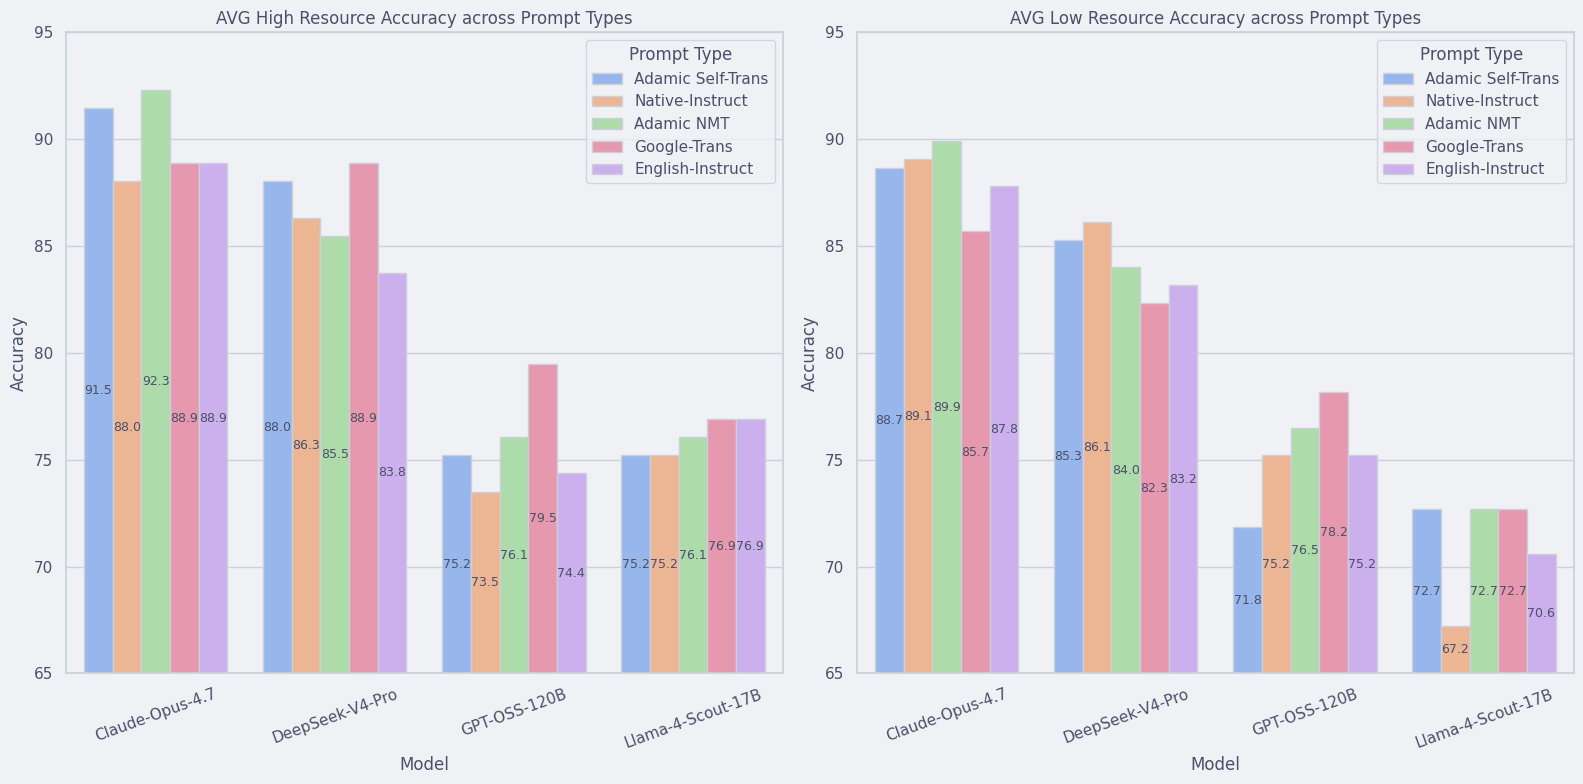

In [180]:
df_cultural_global = df_cultural_global.sort_values(by=["Model", "Prompt Type"])
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

prompt_order = ["Adamic Self-Trans", "Native-Instruct", "Adamic NMT", "Google-Trans", "English-Instruct"]

catppuccin_colors = [
    "#89b4fa",  # blue
    "#fab387",  # peach
    "#a6e3a1",  # green
    "#f38ba8",  # red/pink
    "#cba6f7",  # purple
]
palette = dict(zip(prompt_order, catppuccin_colors))

for ax, col, title in [
    (axes[0], "AVG - High", "AVG High Resource Accuracy across Prompt Types"),
    (axes[1], "AVG - Low", "AVG Low Resource Accuracy across Prompt Types"),
]:
    sns.barplot(
        data=df_cultural_global,
        x="Model",
        y=col,
        hue="Prompt Type",
        hue_order=prompt_order,
        palette=palette,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("Model")
    ax.set_ylim(65, 95)
    ax.set_yticks(np.arange(65, 96, 5))
    ax.tick_params(axis="x", rotation=20)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", label_type="center", fontsize=9)
    #ax.legend(title="Prompt Type", loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## Create main table with all languages and models for each task

In [4]:
path_to_tables = "../benchmarks/result_tables"

In [66]:
df = pd.read_csv(f"{path_to_tables}/global_mmlu_table.csv")

In [ ]:
df

In [67]:
key=None
dic_new_lang_names: dict[str, str] = dict.fromkeys(dic_list_langs_no_en.keys(), [])
for key in dic_list_langs_no_en.keys():
    list_of_langs = dic_list_langs_no_en[key]
    new_list_of_langs = []
    for lang in list_of_langs:
        new_list_of_langs.append(f"{key}_{lang}")
    dic_new_lang_names[key] = new_list_of_langs

In [68]:
key=None
dic_new_lang_names_high_resource: dict[str, str] = dict.fromkeys(dic_list_langs_no_en.keys(), [])
for key in dic_list_langs_no_en.keys():
    list_of_langs = dic_list_langs_no_en_high_resource[key]
    new_list_of_langs = []
    for lang in list_of_langs:
        new_list_of_langs.append(f"{key}_{lang}")
    dic_new_lang_names_high_resource[key] = new_list_of_langs

In [69]:
key=None
dic_new_lang_names_low_resource = dict.fromkeys(dic_list_langs_no_en.keys(), [])
for key in dic_list_langs_no_en.keys():
    list_of_langs = dic_list_langs_no_en_low_resource[key]
    new_list_of_langs = []
    for lang in list_of_langs:
        new_list_of_langs.append(f"{key}_{lang}")
    dic_new_lang_names_low_resource[key] = new_list_of_langs

In [70]:
df.rename(columns=dict(zip(dic_list_langs_no_en["global_mmlu"], dic_new_lang_names["global_mmlu"])), inplace=True)
df.rename(columns={"AVG - high": "Global MMLU - high", "AVG - low": "Global MMLU - low", "AVG - all": "Global MMLU - all"}, inplace=True)

In [72]:
df2 = pd.read_csv(f"{path_to_tables}/xnli_table.csv")

In [73]:
df2.rename(columns=dict(zip(dic_list_langs_no_en["xnli"], dic_new_lang_names["xnli"])), inplace=True)
df2.rename(columns={"AVG - high": "XNLI - high", "AVG - low": "XNLI - low", "AVG - all": "XNLI - all"}, inplace=True)

In [74]:
# meager the two tables on model and prompt type
df_merged = pd.merge(df, df2, on=["Model", "Prompt Type"], how="inner")

In [75]:
df_merged

,Model,Prompt Type,global_mmlu_de,global_mmlu_fa,global_mmlu_fr,global_mmlu_he,global_mmlu_ja,global_mmlu_ne,global_mmlu_pl,global_mmlu_si,...,xnli_sw,xnli_ar,xnli_el,xnli_th,xnli_bg,xnli_hi,xnli_ur,XNLI - high,XNLI - low,XNLI - all
0,Claude-Opus-4.7,Adamic NMT,87.8,92.0,93.6,93.0,91.4,88.8,92.0,87.6,...,78.0,75.6,78.6,67.2,82.2,75.6,75.2,76.700000,75.500,76.014286
1,Claude-Opus-4.7,Adamic Self-Trans,90.6,91.2,93.2,92.6,92.2,90.4,91.6,90.0,...,76.2,76.8,78.2,71.6,78.0,77.2,72.2,77.733333,75.775,76.614286
2,Claude-Opus-4.7,English-Instruct,88.6,92.6,92.8,92.8,93.0,89.6,93.0,88.4,...,75.0,79.6,77.6,75.4,80.0,78.4,76.4,77.066667,77.275,77.185714
3,Claude-Opus-4.7,Google-Trans,89.2,87.6,92.6,91.2,90.8,88.4,91.6,87.2,...,72.0,75.0,75.0,69.2,76.8,68.4,64.0,75.333333,71.650,73.228571
4,Claude-Opus-4.7,Native-Instruct,89.4,92.2,92.4,94.4,92.4,91.0,93.0,90.2,...,76.0,79.4,76.6,70.2,79.8,78.4,71.2,76.466667,75.775,76.071429
5,DeepSeek-V4-Pro,Adamic NMT,83.8,88.6,91.2,90.0,88.6,87.8,90.2,87.0,...,54.4,59.8,61.8,56.8,65.0,59.8,53.2,59.433333,57.850,58.528571
6,DeepSeek-V4-Pro,Adamic Self-Trans,84.6,91.4,92.0,90.8,90.6,88.4,92.0,88.8,...,50.0,55.6,56.8,56.2,58.2,53.8,52.4,55.200000,54.175,54.614286
7,DeepSeek-V4-Pro,English-Instruct,82.2,90.4,92.4,87.8,90.0,80.4,92.0,88.8,...,56.0,64.0,64.8,60.8,66.0,59.6,58.6,63.766667,61.050,62.214286
8,DeepSeek-V4-Pro,Google-Trans,88.6,88.2,90.8,89.8,89.4,87.6,91.6,86.2,...,60.8,64.2,65.2,59.8,65.8,58.2,54.6,63.766667,61.400,62.414286
9,DeepSeek-V4-Pro,Native-Instruct,85.6,90.0,93.2,92.4,90.4,89.2,91.6,88.6,...,52.8,52.4,57.0,52.2,60.0,50.6,50.8,54.600000,53.025,53.700000


In [76]:
df3 = pd.read_csv(f"{path_to_tables}/paws-x_table.csv")
df3.rename(columns=dict(zip(dic_list_langs_no_en["paws-x"], dic_new_lang_names["paws-x"])), inplace=True)
df3.rename(columns={"AVG - high": "PAWS-X - high", "AVG - low": "PAWS-X - low", "AVG - all": "PAWS-X - all"}, inplace=True)
df_merged = pd.merge(df_merged, df3, on=["Model", "Prompt Type"], how="inner")

In [77]:
df4 = pd.read_csv(f"{path_to_tables}/mmmlu_table.csv")
df4.rename(columns=dict(zip(dic_list_langs_no_en["mmmlu"], dic_new_lang_names["mmmlu"])), inplace=True)
df4.rename(columns={"AVG - high": "MMLU - high", "AVG - low": "MMLU - low", "AVG - all": "MMLU - all"}, inplace=True)
df_merged = pd.merge(df_merged, df4, on=["Model", "Prompt Type"], how="inner")

In [78]:
df5 = pd.read_csv(f"{path_to_tables}/mkqa_table.csv")
df5.rename(columns=dict(zip(dic_list_langs_no_en["mkqa"], dic_new_lang_names["mkqa"])), inplace=True)
df5.rename(columns={"AVG - high": "MKQA - high", "AVG - low": "MKQA - low", "AVG - all": "MKQA - all"}, inplace=True)
df_merged = pd.merge(df_merged, df5, on=["Model", "Prompt Type"], how="inner")

In [79]:
df6 = pd.read_csv(f"{path_to_tables}/xlsum_table.csv")
df6.rename(columns=dict(zip(dic_list_langs_no_en["xlsum"], dic_new_lang_names["xlsum"])), inplace=True)
df6.rename(columns={"AVG - high": "XLSUM - high", "AVG - low": "XLSUM - low", "AVG - all": "XLSUM - all"}, inplace=True)
df_merged = pd.merge(df_merged, df6, on=["Model", "Prompt Type"], how="inner")

In [80]:
df_merged

,Model,Prompt Type,global_mmlu_de,global_mmlu_fa,global_mmlu_fr,global_mmlu_he,global_mmlu_ja,global_mmlu_ne,global_mmlu_pl,global_mmlu_si,...,MKQA - low,MKQA - all,xlsum_fr,xlsum_zh,xlsum_es,xlsum_vi,xlsum_tr,XLSUM - high,XLSUM - low,XLSUM - all
0,Claude-Opus-4.7,Adamic NMT,87.8,92.0,93.6,93.0,91.4,88.8,92.0,87.6,...,52.943029,50.388922,26.789166,38.651063,27.027853,30.664031,31.815330,30.783028,31.815330,30.989488
1,Claude-Opus-4.7,Adamic Self-Trans,90.6,91.2,93.2,92.6,92.2,90.4,91.6,90.0,...,53.180688,52.363348,26.963277,37.560000,25.532990,23.937186,30.691145,28.498363,30.691145,28.936920
2,Claude-Opus-4.7,English-Instruct,88.6,92.6,92.8,92.8,93.0,89.6,93.0,88.4,...,50.741977,50.310781,28.361266,38.673064,27.177062,34.221190,32.166472,32.108146,32.166472,32.119811
3,Claude-Opus-4.7,Google-Trans,89.2,87.6,92.6,91.2,90.8,88.4,91.6,87.2,...,51.017617,49.872258,23.844962,33.341467,25.148305,30.939604,26.399663,28.318584,26.399663,27.934800
4,Claude-Opus-4.7,Native-Instruct,89.4,92.2,92.4,94.4,92.4,91.0,93.0,90.2,...,52.283295,51.177426,27.959066,40.118575,26.621861,24.414322,31.753185,29.778456,31.753185,30.173402
5,DeepSeek-V4-Pro,Adamic NMT,83.8,88.6,91.2,90.0,88.6,87.8,90.2,87.0,...,51.518368,49.979070,26.392271,34.756228,26.882547,30.368427,29.326700,29.599868,29.326700,29.545235
6,DeepSeek-V4-Pro,Adamic Self-Trans,84.6,91.4,92.0,90.8,90.6,88.4,92.0,88.8,...,51.595976,51.244736,27.269733,36.608831,26.310673,29.699806,30.677790,29.972261,30.677790,30.113366
7,DeepSeek-V4-Pro,English-Instruct,82.2,90.4,92.4,87.8,90.0,80.4,92.0,88.8,...,48.593007,49.696780,28.028829,37.321492,26.542521,26.326470,30.114061,29.554828,30.114061,29.666675
8,DeepSeek-V4-Pro,Google-Trans,88.6,88.2,90.8,89.8,89.4,87.6,91.6,86.2,...,50.153187,49.830272,23.735286,33.223538,25.307579,31.037400,26.923977,28.325951,26.923977,28.045556
9,DeepSeek-V4-Pro,Native-Instruct,85.6,90.0,93.2,92.4,90.4,89.2,91.6,88.6,...,52.936340,50.359707,26.514720,35.934367,25.845010,30.991035,29.833182,29.821283,29.833182,29.823663


### Get weighted average of and unweighted average of all languages for each model and task

In [90]:
df_merged_avg_weighted = df_merged.copy()
df_merged_avg_none_weighted = df_merged.copy()

#### weighted average (average across all languages)

In [91]:
all_low_resource_cols = None
all_low_resource_cols: list[str] = []
for key in dic_list_langs_no_en.keys():
    all_low_resource_cols += dic_new_lang_names_low_resource[key]

In [92]:
all_high_resource_cols = None
all_high_resource_cols: list[str] = []
for key in dic_list_langs_no_en.keys():
    all_high_resource_cols += dic_new_lang_names_high_resource[key]

In [93]:
df_merged_avg_weighted["AVG - high"] = df_merged_avg_weighted[all_high_resource_cols].mean(axis=1)

In [94]:
df_merged_avg_weighted["AVG - low"] = df_merged_avg_weighted[all_low_resource_cols].mean(axis=1)

In [95]:
df_merged_avg_weighted["AVG - ALL"] = df_merged_avg_weighted[all_low_resource_cols + all_high_resource_cols].mean(axis=1)

In [96]:
df_merged_avg_weighted.drop(columns=["XLSUM - all", "MKQA - all", "Global MMLU - all", "XNLI - all", "PAWS-X - all", "MMLU - all"], inplace=True)

In [97]:
df_merged_avg_weighted.drop(columns=all_high_resource_cols + all_low_resource_cols, inplace=True)

In [98]:
df_merged_avg_weighted

,Model,Prompt Type,Global MMLU - high,Global MMLU - low,XNLI - high,XNLI - low,PAWS-X - high,PAWS-X - low,MMLU - high,MMLU - low,MKQA - high,MKQA - low,XLSUM - high,XLSUM - low,AVG - high,AVG - low,AVG - ALL
0,Claude-Opus-4.7,Adamic NMT,91.20,88.355556,76.700000,75.500,77.60,74.0,91.400,87.133333,49.659177,52.943029,30.783028,31.815330,71.027834,79.025977,74.567996
1,Claude-Opus-4.7,Adamic Self-Trans,91.90,89.066667,77.733333,75.775,77.88,74.4,92.425,88.200000,52.129822,53.180688,28.498363,30.691145,71.814771,79.572316,75.248438
2,Claude-Opus-4.7,English-Instruct,91.85,88.688889,77.066667,77.275,79.92,77.0,92.025,87.866667,50.187582,50.741977,32.108146,32.166472,71.921931,79.787053,75.403214
3,Claude-Opus-4.7,Google-Trans,91.05,86.244444,75.333333,71.650,76.04,71.4,90.425,83.500000,49.545012,51.017617,28.318584,26.399663,69.996748,75.934626,72.624989
4,Claude-Opus-4.7,Native-Instruct,91.80,89.400000,76.466667,75.775,79.40,77.0,91.975,88.333333,50.861464,52.283295,29.778456,31.753185,71.586590,79.782214,75.214161
5,DeepSeek-V4-Pro,Adamic NMT,88.45,86.311111,59.433333,57.850,72.52,70.6,88.825,83.966667,49.539270,51.518368,29.599868,29.326700,66.140423,72.087535,68.772751
6,DeepSeek-V4-Pro,Adamic Self-Trans,89.80,86.844444,55.200000,54.175,70.64,68.8,89.225,84.566667,51.144381,51.595976,29.972261,30.677790,65.744109,71.298879,68.202778
7,DeepSeek-V4-Pro,English-Instruct,89.15,86.444444,63.766667,61.050,69.12,69.0,89.150,84.233333,50.012144,48.593007,29.554828,30.114061,66.656009,72.892595,69.416466
8,DeepSeek-V4-Pro,Google-Trans,90.10,85.533333,63.766667,61.400,69.44,65.6,88.700,82.508333,49.738011,50.153187,28.325951,26.923977,66.507938,72.180754,69.018856
9,DeepSeek-V4-Pro,Native-Instruct,90.20,87.888889,54.600000,53.025,71.72,75.2,89.900,85.666667,49.623526,52.936340,29.821283,29.833182,65.672053,71.855773,68.409109


#### unweighted average (average across all test)

In [99]:
df_merged_avg_none_weighted["AVG - high"] = df_merged_avg_none_weighted[["Global MMLU - high", "XNLI - high", "PAWS-X - high", "MMLU - high", "MKQA - high", "XLSUM - high"]].mean(axis=1)

In [100]:
df_merged_avg_none_weighted["AVG - low"] = df_merged_avg_none_weighted[["Global MMLU - low", "XNLI - low", "PAWS-X - low", "MMLU - low", "MKQA - low", "XLSUM - low"]].mean(axis=1)

In [101]:
df_merged_avg_none_weighted["AVG - ALL"] = df_merged_avg_none_weighted[["Global MMLU - all", "XNLI - all", "PAWS-X - all", "MMLU - all", "MKQA - all", "XLSUM - all"]].mean(axis=1)

In [102]:
df_merged_avg_none_weighted.drop(columns=["XLSUM - all", "MKQA - all", "Global MMLU - all", "XNLI - all", "PAWS-X - all", "MMLU - all"], inplace=True)
df_merged_avg_none_weighted.drop(columns=all_high_resource_cols + all_low_resource_cols, inplace=True)

In [103]:
df_merged_avg_none_weighted

,Model,Prompt Type,Global MMLU - high,Global MMLU - low,XNLI - high,XNLI - low,PAWS-X - high,PAWS-X - low,MMLU - high,MMLU - low,MKQA - high,MKQA - low,XLSUM - high,XLSUM - low,AVG - high,AVG - low,AVG - ALL
0,Claude-Opus-4.7,Adamic NMT,91.20,88.355556,76.700000,75.500,77.60,74.0,91.400,87.133333,49.659177,52.943029,30.783028,31.815330,69.557034,68.291208,68.865816
1,Claude-Opus-4.7,Adamic Self-Trans,91.90,89.066667,77.733333,75.775,77.88,74.4,92.425,88.200000,52.129822,53.180688,28.498363,30.691145,70.094420,68.552250,69.294550
2,Claude-Opus-4.7,English-Instruct,91.85,88.688889,77.066667,77.275,79.92,77.0,92.025,87.866667,50.187582,50.741977,32.108146,32.166472,70.526232,68.956501,69.825673
3,Claude-Opus-4.7,Google-Trans,91.05,86.244444,75.333333,71.650,76.04,71.4,90.425,83.500000,49.545012,51.017617,28.318584,26.399663,68.451988,65.035288,66.913753
4,Claude-Opus-4.7,Native-Instruct,91.80,89.400000,76.466667,75.775,79.40,77.0,91.975,88.333333,50.861464,52.283295,29.778456,31.753185,70.046931,69.090802,69.495834
5,DeepSeek-V4-Pro,Adamic NMT,88.45,86.311111,59.433333,57.850,72.52,70.6,88.825,83.966667,49.539270,51.518368,29.599868,29.326700,64.727912,63.262141,63.994161
6,DeepSeek-V4-Pro,Adamic Self-Trans,89.80,86.844444,55.200000,54.175,70.64,68.8,89.225,84.566667,51.144381,51.595976,29.972261,30.677790,64.330274,62.776646,63.548023
7,DeepSeek-V4-Pro,English-Instruct,89.15,86.444444,63.766667,61.050,69.12,69.0,89.150,84.233333,50.012144,48.593007,29.554828,30.114061,65.125606,63.239141,64.166253
8,DeepSeek-V4-Pro,Google-Trans,90.10,85.533333,63.766667,61.400,69.44,65.6,88.700,82.508333,49.738011,50.153187,28.325951,26.923977,65.011771,62.019805,63.679167
9,DeepSeek-V4-Pro,Native-Instruct,90.20,87.888889,54.600000,53.025,71.72,75.2,89.900,85.666667,49.623526,52.936340,29.821283,29.833182,64.310802,64.091680,63.811514


In [104]:
df_merged_avg_weighted.to_csv(f"{path_to_tables}/main_table_weighted.csv", index=False)

In [105]:
df_merged_avg_none_weighted.to_csv(f"{path_to_tables}/main_table_unweighted.csv", index=False)

In [106]:
#rounded versions of the tables for better visualization in the paper
df_merged_avg_weighted_rounded = df_merged_avg_weighted.copy()
for col in df_merged_avg_weighted_rounded.columns:
    if col not in ["Model", "Prompt Type"]:
        df_merged_avg_weighted_rounded[col] = df_merged_avg_weighted_rounded[col].round(2) 
df_merged_avg_none_weighted_rounded = df_merged_avg_none_weighted.copy()
for col in df_merged_avg_none_weighted_rounded.columns:
    if col not in ["Model", "Prompt Type"]:
        df_merged_avg_none_weighted_rounded[col] = df_merged_avg_none_weighted_rounded[col].round(2)

In [107]:
df_merged_avg_weighted_rounded

,Model,Prompt Type,Global MMLU - high,Global MMLU - low,XNLI - high,XNLI - low,PAWS-X - high,PAWS-X - low,MMLU - high,MMLU - low,MKQA - high,MKQA - low,XLSUM - high,XLSUM - low,AVG - high,AVG - low,AVG - ALL
0,Claude-Opus-4.7,Adamic NMT,91.20,88.36,76.70,75.50,77.60,74.0,91.40,87.13,49.66,52.94,30.78,31.82,71.03,79.03,74.57
1,Claude-Opus-4.7,Adamic Self-Trans,91.90,89.07,77.73,75.78,77.88,74.4,92.42,88.20,52.13,53.18,28.50,30.69,71.81,79.57,75.25
2,Claude-Opus-4.7,English-Instruct,91.85,88.69,77.07,77.28,79.92,77.0,92.02,87.87,50.19,50.74,32.11,32.17,71.92,79.79,75.40
3,Claude-Opus-4.7,Google-Trans,91.05,86.24,75.33,71.65,76.04,71.4,90.42,83.50,49.55,51.02,28.32,26.40,70.00,75.93,72.62
4,Claude-Opus-4.7,Native-Instruct,91.80,89.40,76.47,75.78,79.40,77.0,91.98,88.33,50.86,52.28,29.78,31.75,71.59,79.78,75.21
5,DeepSeek-V4-Pro,Adamic NMT,88.45,86.31,59.43,57.85,72.52,70.6,88.82,83.97,49.54,51.52,29.60,29.33,66.14,72.09,68.77
6,DeepSeek-V4-Pro,Adamic Self-Trans,89.80,86.84,55.20,54.18,70.64,68.8,89.22,84.57,51.14,51.60,29.97,30.68,65.74,71.30,68.20
7,DeepSeek-V4-Pro,English-Instruct,89.15,86.44,63.77,61.05,69.12,69.0,89.15,84.23,50.01,48.59,29.55,30.11,66.66,72.89,69.42
8,DeepSeek-V4-Pro,Google-Trans,90.10,85.53,63.77,61.40,69.44,65.6,88.70,82.51,49.74,50.15,28.33,26.92,66.51,72.18,69.02
9,DeepSeek-V4-Pro,Native-Instruct,90.20,87.89,54.60,53.03,71.72,75.2,89.90,85.67,49.62,52.94,29.82,29.83,65.67,71.86,68.41


In [108]:
df_merged_avg_none_weighted_rounded

,Model,Prompt Type,Global MMLU - high,Global MMLU - low,XNLI - high,XNLI - low,PAWS-X - high,PAWS-X - low,MMLU - high,MMLU - low,MKQA - high,MKQA - low,XLSUM - high,XLSUM - low,AVG - high,AVG - low,AVG - ALL
0,Claude-Opus-4.7,Adamic NMT,91.20,88.36,76.70,75.50,77.60,74.0,91.40,87.13,49.66,52.94,30.78,31.82,69.56,68.29,68.87
1,Claude-Opus-4.7,Adamic Self-Trans,91.90,89.07,77.73,75.78,77.88,74.4,92.42,88.20,52.13,53.18,28.50,30.69,70.09,68.55,69.29
2,Claude-Opus-4.7,English-Instruct,91.85,88.69,77.07,77.28,79.92,77.0,92.02,87.87,50.19,50.74,32.11,32.17,70.53,68.96,69.83
3,Claude-Opus-4.7,Google-Trans,91.05,86.24,75.33,71.65,76.04,71.4,90.42,83.50,49.55,51.02,28.32,26.40,68.45,65.04,66.91
4,Claude-Opus-4.7,Native-Instruct,91.80,89.40,76.47,75.78,79.40,77.0,91.98,88.33,50.86,52.28,29.78,31.75,70.05,69.09,69.50
5,DeepSeek-V4-Pro,Adamic NMT,88.45,86.31,59.43,57.85,72.52,70.6,88.82,83.97,49.54,51.52,29.60,29.33,64.73,63.26,63.99
6,DeepSeek-V4-Pro,Adamic Self-Trans,89.80,86.84,55.20,54.18,70.64,68.8,89.22,84.57,51.14,51.60,29.97,30.68,64.33,62.78,63.55
7,DeepSeek-V4-Pro,English-Instruct,89.15,86.44,63.77,61.05,69.12,69.0,89.15,84.23,50.01,48.59,29.55,30.11,65.13,63.24,64.17
8,DeepSeek-V4-Pro,Google-Trans,90.10,85.53,63.77,61.40,69.44,65.6,88.70,82.51,49.74,50.15,28.33,26.92,65.01,62.02,63.68
9,DeepSeek-V4-Pro,Native-Instruct,90.20,87.89,54.60,53.03,71.72,75.2,89.90,85.67,49.62,52.94,29.82,29.83,64.31,64.09,63.81


In [109]:
## save the rounded tables
df_merged_avg_weighted_rounded.to_csv(f"{path_to_tables}/main_table_weighted_rounded.csv", index=False)
df_merged_avg_none_weighted_rounded.to_csv(f"{path_to_tables}/main_table_unweighted_rounded.csv", index=False)

## Barplot

In [5]:
df_main = pd.read_csv(f"{path_to_tables}/main_table_unweighted.csv")

In [144]:
df_main

,Model,Prompt Type,Global MMLU - high,Global MMLU - low,XNLI - high,XNLI - low,PAWS-X - high,PAWS-X - low,MMLU - high,MMLU - low,MKQA - high,MKQA - low,XLSUM - high,XLSUM - low,AVG - high,AVG - low,AVG - ALL
0,Claude-Opus-4.7,Adamic NMT,91.20,88.355556,76.700000,75.500,77.60,74.0,91.400,87.133333,49.659177,52.943029,30.783028,31.815330,69.557034,68.291208,68.865816
1,Claude-Opus-4.7,Adamic Self-Trans,91.90,89.066667,77.733333,75.775,77.88,74.4,92.425,88.200000,52.129822,53.180688,28.498363,30.691145,70.094420,68.552250,69.294550
2,Claude-Opus-4.7,English-Instruct,91.85,88.688889,77.066667,77.275,79.92,77.0,92.025,87.866667,50.187582,50.741977,32.108146,32.166472,70.526232,68.956501,69.825673
3,Claude-Opus-4.7,Google-Trans,91.05,86.244444,75.333333,71.650,76.04,71.4,90.425,83.500000,49.545012,51.017617,28.318584,26.399663,68.451988,65.035288,66.913753
4,Claude-Opus-4.7,Native-Instruct,91.80,89.400000,76.466667,75.775,79.40,77.0,91.975,88.333333,50.861464,52.283295,29.778456,31.753185,70.046931,69.090802,69.495834
5,DeepSeek-V4-Pro,Adamic NMT,88.45,86.311111,59.433333,57.850,72.52,70.6,88.825,83.966667,49.539270,51.518368,29.599868,29.326700,64.727912,63.262141,63.994161
6,DeepSeek-V4-Pro,Adamic Self-Trans,89.80,86.844444,55.200000,54.175,70.64,68.8,89.225,84.566667,51.144381,51.595976,29.972261,30.677790,64.330274,62.776646,63.548023
7,DeepSeek-V4-Pro,English-Instruct,89.15,86.444444,63.766667,61.050,69.12,69.0,89.150,84.233333,50.012144,48.593007,29.554828,30.114061,65.125606,63.239141,64.166253
8,DeepSeek-V4-Pro,Google-Trans,90.10,85.533333,63.766667,61.400,69.44,65.6,88.700,82.508333,49.738011,50.153187,28.325951,26.923977,65.011771,62.019805,63.679167
9,DeepSeek-V4-Pro,Native-Instruct,90.20,87.888889,54.600000,53.025,71.72,75.2,89.900,85.666667,49.623526,52.936340,29.821283,29.833182,64.310802,64.091680,63.811514


In [93]:
df_main = df_main.sort_values(by=["Model", "Prompt Type"], ascending=[False, True])

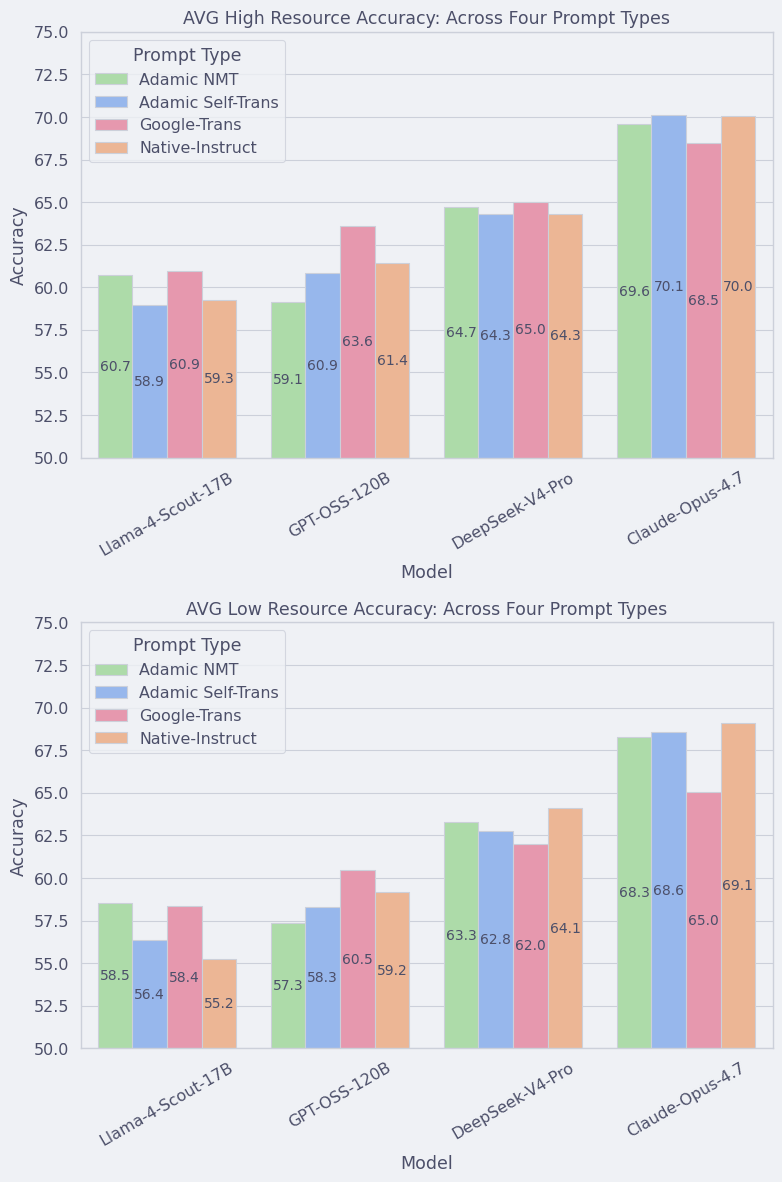

In [94]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

df_plot = df_main[df_main["Prompt Type"].isin(["Adamic Self-Trans", "Native-Instruct", "Adamic NMT", "Google-Trans"])]
# Catppuccin Mocha palette
catppuccin_colors = [
    "#89b4fa",  # blue
    "#fab387",  # peach
    "#a6e3a1",  # green
    "#f38ba8",  # red/pink
]

for ax, col, title in [
    (axes[0], "AVG - high", "AVG High Resource Accuracy: Across Four Prompt Types"),
    (axes[1], "AVG - low", "AVG Low Resource Accuracy: Across Four Prompt Types"),
]:
    sns.barplot(data=df_plot, x="Model", y=col, hue="Prompt Type", ax=ax, palette=dict(zip(["Adamic Self-Trans", "Native-Instruct", "Adamic NMT", "Google-Trans"], catppuccin_colors)))
    ax.set_title(title)
    ax.set_ylim(51, 75)
    ax.set_ylabel("Accuracy")
    ax.set_yticks(np.arange(50, 76, 2.5))
    ax.tick_params(axis='x', rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", label_type="center", fontsize=10)

plt.tight_layout()
plt.show()

In [39]:
fig.savefig("fig_admic_performance.pdf", bbox_inches="tight", transparent=True)

In [ ]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

prompt_order = ["adamic", "google_direct", "direct", "direct_native", "adamic_self_trans"]
df_plot = df_main[df_main["Prompt Type"].isin(prompt_order)]

# Catppuccin Mocha palette
catppuccin_colors = [
    "#89b4fa",  # blue
    "#fab387",  # peach
    "#a6e3a1",  # green
    "#f38ba8",  # red/pink
    "#f5c2e7",  # purple
]
palette = dict(zip(prompt_order, catppuccin_colors))

for ax, col, title in [
    (axes[0], "AVG - high", "AVG High Resource Accuracy"),
        (axes[1], "AVG - low", "AVG Low Resource Accuracy"),
    ]:
    # Sort prompt types within each model by accuracy (descending)
    df_sorted = (
        df_plot.sort_values(["Model", col], ascending=[True, False])
        .reset_index(drop=True)
    )
    df_sorted["Rank"] = df_sorted.groupby("Model")[col].rank(method="first", ascending=False).astype(int)

    models = df_sorted["Model"].unique().tolist()
    ranks = sorted(df_sorted["Rank"].unique())
    n_ranks = len(ranks)

    x = np.arange(len(models))
    width = 0.8 / n_ranks

    for i, rank in enumerate(ranks):
        heights = []
        colors = []
        labels = []
        for model in models:
            row = df_sorted[(df_sorted["Model"] == model) & (df_sorted["Rank"] == rank)]
            if not row.empty:
                val = row[col].values[0]
                pt = row["Prompt Type"].values[0]
                heights.append(val)
                colors.append(palette[pt])
                labels.append(f"{val:.1f}")
            else:
                heights.append(0)
                colors.append((0, 0, 0, 0))
                labels.append("")
        positions = x - 0.4 + width / 2 + i * width
        bars = ax.bar(positions, heights, width=width, color=colors)
        ax.bar_label(bars, labels=labels, label_type="center", fontsize=8)

    # Legend by Prompt Type
    legend_handles = [Patch(facecolor=palette[pt], label=pt) for pt in prompt_order]
    ax.legend(handles=legend_handles, title="Prompt Type")

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30)
    ax.set_title(title)
    ax.set_ylim(0, 90)
    ax.set_ylabel("Accuracy")
    ax.set_yticks(np.arange(0, 91, 5))
    ax.set_xlabel("Model")

plt.tight_layout()
plt.show()

In [48]:
import math
#inserting the models base performance on the GPQA Diamond bencmark
model_base_performance = {
    "Llama-4-Scout-17B": 57.2,
    "GPT-OSS-120B": 80.1,
    "DeepSeek-V4-Pro": 90.1,
    "Claude-Opus-4.7": 94.2,
}


# get the log of performance for each model and create a dataframe

#for model, performance in model_base_performance.items():
#    model_base_performance[model] = math.log(performance)

df_model_base_performance = pd.DataFrame(list(model_base_performance.items()), columns=["Model", "GPQA Diamond"])


# add the GPQA Diamond performance to the main table
df_main_with_gpqa = pd.merge(df_main, df_model_base_performance, on="Model", how="left")
df_main_with_gpqa

,Model,Prompt Type,Global MMLU - high,Global MMLU - low,XNLI - high,XNLI - low,PAWS-X - high,PAWS-X - low,MMLU - high,MMLU - low,MKQA - high,MKQA - low,XLSUM - high,XLSUM - low,AVG - high,AVG - low,AVG - ALL,GPQA Diamond
0,Claude-Opus-4.7,Adamic NMT,91.20,88.355556,76.700000,75.500,77.60,74.0,91.400,87.133333,49.659177,52.943029,30.783028,31.815330,69.557034,68.291208,68.865816,94.2
1,Claude-Opus-4.7,Adamic Self-Trans,91.90,89.066667,77.733333,75.775,77.88,74.4,92.425,88.200000,52.129822,53.180688,28.498363,30.691145,70.094420,68.552250,69.294550,94.2
2,Claude-Opus-4.7,English-Instruct,91.85,88.688889,77.066667,77.275,79.92,77.0,92.025,87.866667,50.187582,50.741977,32.108146,32.166472,70.526232,68.956501,69.825673,94.2
3,Claude-Opus-4.7,Google-Trans,91.05,86.244444,75.333333,71.650,76.04,71.4,90.425,83.500000,49.545012,51.017617,28.318584,26.399663,68.451988,65.035288,66.913753,94.2
4,Claude-Opus-4.7,Native-Instruct,91.80,89.400000,76.466667,75.775,79.40,77.0,91.975,88.333333,50.861464,52.283295,29.778456,31.753185,70.046931,69.090802,69.495834,94.2
5,DeepSeek-V4-Pro,Adamic NMT,88.45,86.311111,59.433333,57.850,72.52,70.6,88.825,83.966667,49.539270,51.518368,29.599868,29.326700,64.727912,63.262141,63.994161,90.1
6,DeepSeek-V4-Pro,Adamic Self-Trans,89.80,86.844444,55.200000,54.175,70.64,68.8,89.225,84.566667,51.144381,51.595976,29.972261,30.677790,64.330274,62.776646,63.548023,90.1
7,DeepSeek-V4-Pro,English-Instruct,89.15,86.444444,63.766667,61.050,69.12,69.0,89.150,84.233333,50.012144,48.593007,29.554828,30.114061,65.125606,63.239141,64.166253,90.1
8,DeepSeek-V4-Pro,Google-Trans,90.10,85.533333,63.766667,61.400,69.44,65.6,88.700,82.508333,49.738011,50.153187,28.325951,26.923977,65.011771,62.019805,63.679167,90.1
9,DeepSeek-V4-Pro,Native-Instruct,90.20,87.888889,54.600000,53.025,71.72,75.2,89.900,85.666667,49.623526,52.936340,29.821283,29.833182,64.310802,64.091680,63.811514,90.1


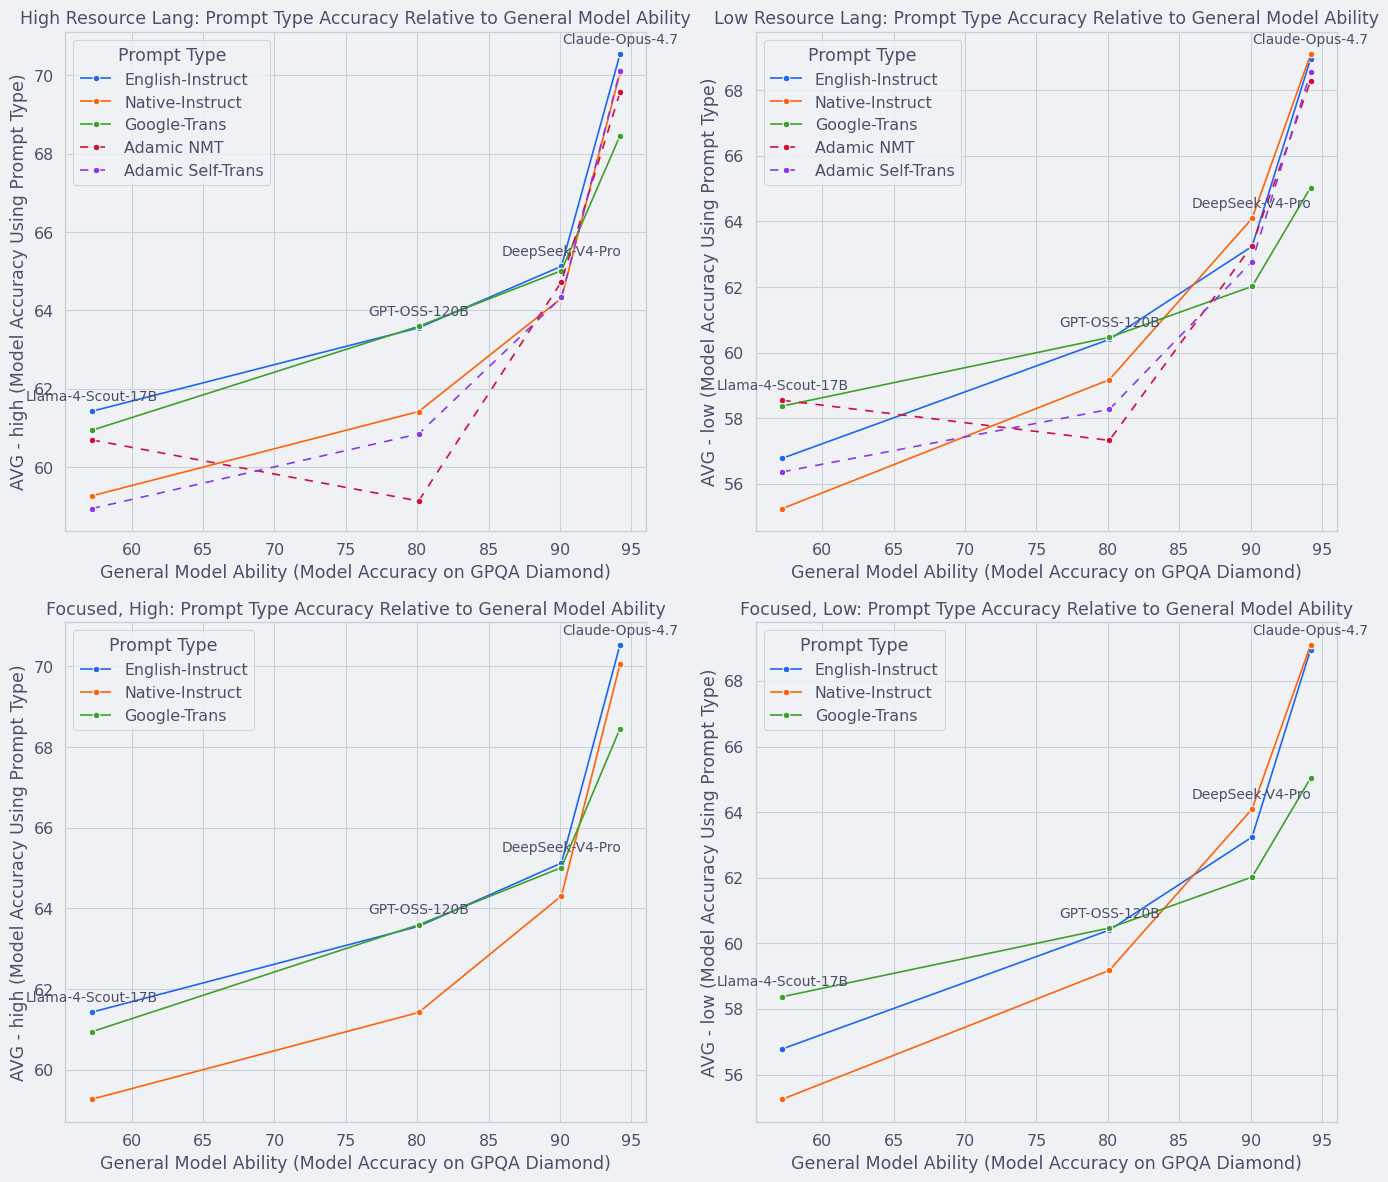

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
count = 0
sns.set_context('paper', font_scale=1.3)
# Catppuccin Mocha palette
catppuccin_colors = [
    "#89b4fa",  # blue
    "#fab387",  # peach
    "#a6e3a1",  # green
    "#f38ba8",  # red/pink
    "#f5c2e7",  # purple
]

dash_patterns = [(1, 0), (1, 0), (1, 0), (5, 5), (5, 5)]

for ax, col, title in [
    (axes[0, 0], "AVG - high", "High Resource Lang: Prompt Type Accuracy Relative to General Model Ability"),
    (axes[0, 1], "AVG - low", "Low Resource Lang: Prompt Type Accuracy Relative to General Model Ability"),
    (axes[1, 0], "AVG - high", "Focused, High: Prompt Type Accuracy Relative to General Model Ability"),
    (axes[1, 1], "AVG - low", "Focused, Low: Prompt Type Accuracy Relative to General Model Ability"),
]:
    base_line_model_scores = (
        df_main_with_gpqa.groupby("Model")["GPQA Diamond"]
        .first()
        .sort_values()
    )
    base_line_model_scores_sorted = base_line_model_scores.index.tolist()

    direct_scores = df_main[df_main["Prompt Type"] == "English-Instruct"].set_index("Model")[col]
    direct_native_scores = df_main[df_main["Prompt Type"] == "Native-Instruct"].set_index("Model")[col]
    google_scores = df_main[df_main["Prompt Type"] == "Google-Trans"].set_index("Model")[col]

    plot_df = pd.DataFrame({
        "Model": base_line_model_scores_sorted,
        "x (GPQA Diamond)": [base_line_model_scores[m] for m in base_line_model_scores_sorted],
        "English-Instruct": [direct_scores[m] for m in base_line_model_scores_sorted],
        "Native-Instruct": [direct_native_scores[m] for m in base_line_model_scores_sorted],
        "Google-Trans": [google_scores[m] for m in base_line_model_scores_sorted],
    })

    value_cols = ["English-Instruct", "Native-Instruct", "Google-Trans"]
    if count < 2:
        adamic_scores = df_main[df_main["Prompt Type"] == "Adamic NMT"].set_index("Model")[col]
        plot_df["Adamic NMT"] = [adamic_scores[m] for m in base_line_model_scores_sorted]
        value_cols.append("Adamic NMT")
        adamic_scores_self = df_main[df_main["Prompt Type"] == "Adamic Self-Trans"].set_index("Model")[col]
        plot_df["Adamic Self-Trans"] = [adamic_scores_self[m] for m in base_line_model_scores_sorted]
        value_cols.append("Adamic Self-Trans")

    long_df = plot_df.melt(
        id_vars=["Model", "x (GPQA Diamond)"],
        value_vars=value_cols,
        var_name="Prompt Type",
        value_name="Accuracy",
    )

    dashes_dict = {pt: dash_patterns[i] for i, pt in enumerate(value_cols)}

    sns.lineplot(
        data=long_df,
        x="x (GPQA Diamond)",
        y="Accuracy",
        hue="Prompt Type",
        style="Prompt Type",
        marker="o",
        dashes=dashes_dict,
        ax=ax,
    )

    label_df = (
        long_df.groupby("Model", as_index=False)
        .agg({
            "x (GPQA Diamond)": "first",
            "Accuracy": "max"
        })
    )

    for _, row in label_df.iterrows():
        ax.annotate(
            row["Model"],
            (row["x (GPQA Diamond)"], row["Accuracy"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=10,
        )
    ax.set_title(title)
    ax.set_xlabel("General Model Ability (Model Accuracy on GPQA Diamond)")
    ax.set_ylabel(f"{col} (Model Accuracy Using Prompt Type)")
    count += 1

plt.tight_layout()
plt.show()


In [92]:
fig.savefig("fig_infliction_point.pdf", bbox_inches="tight", transparent=True)

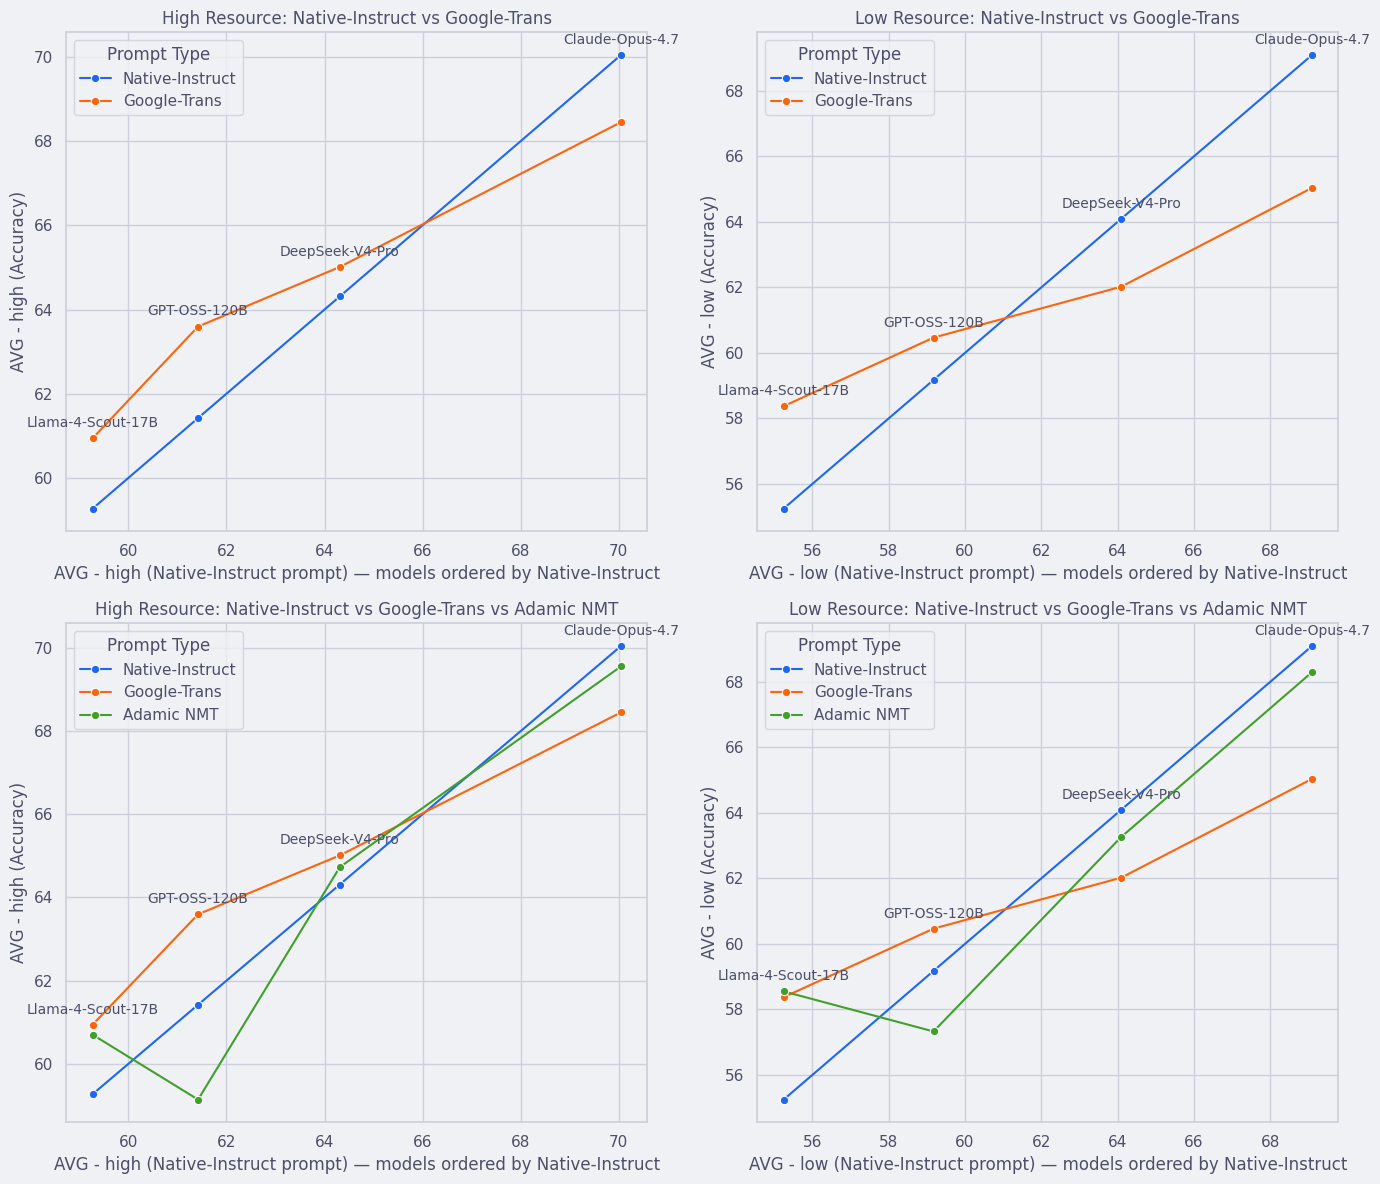

In [ ]:
# For each model, plot points where x = direct accuracy (sorted),
# and y = accuracy of "direct_native" and "Google-Trans" prompt types.
# Compare for both AVG - high and AVG - LOW.

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
count = 0
for ax, col, title in [
    (axes[0, 0], "AVG - high", "High Resource: Native-Instruct vs Google-Trans"),
    (axes[0, 1], "AVG - low", "Low Resource: Native-Instruct vs Google-Trans"),
    (axes[1, 0], "AVG - high", "High Resource: Native-Instruct vs Google-Trans vs Adamic NMT"),
    (axes[1, 1], "AVG - low", "Low Resource: Native-Instruct vs Google-Trans vs Adamic NMT"),
]:
    # Sort models by their direct_native score
    direct_scores = (
        df_main[df_main["Prompt Type"] == "Native-Instruct"]
        .set_index("Model")[col]
        .sort_values()
    )
    sorted_models = direct_scores.index.tolist()

    native_scores = df_main[df_main["Prompt Type"] == "Native-Instruct"].set_index("Model")[col]
    google_scores = df_main[df_main["Prompt Type"] == "Google-Trans"].set_index("Model")[col]

    plot_df = pd.DataFrame({
        "Model": sorted_models,
        "x (Native-Instruct score)": [direct_scores[m] for m in sorted_models],
        "Native-Instruct": [native_scores[m] for m in sorted_models],
        "Google-Trans": [google_scores[m] for m in sorted_models],
    })
    if count >= 2:
        adamic_scores = df_main[df_main["Prompt Type"] == "Adamic NMT"].set_index("Model")[col]
        plot_df["Adamic NMT"] = [adamic_scores[m] for m in sorted_models]
        
    long_df = plot_df.melt(
        id_vars=["Model", "x (Native-Instruct score)"],
        value_vars=["Native-Instruct", "Google-Trans"] + (["Adamic NMT"] if count >= 2 else []),
        var_name="Prompt Type",
        value_name="Accuracy",
    )

    sns.lineplot(
        data=long_df,
        x="x (Native-Instruct score)",
        y="Accuracy",
        hue="Prompt Type",
        marker="o",
        ax=ax,
    )

    label_df = (
        long_df.groupby("Model", as_index=False)
        .agg({
            "x (Native-Instruct score)": "first",
            "Accuracy": "max"
        })
    )

    for _, row in label_df.iterrows():
        ax.annotate(
            row["Model"],
            (row["x (Native-Instruct score)"], row["Accuracy"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=10,
        )

    ax.set_title(title)
    ax.set_xlabel(f"{col} (Native-Instruct prompt) — models ordered by Native-Instruct")
    ax.set_ylabel(f"{col} (Accuracy)")
    count += 1

plt.tight_layout()
plt.show()


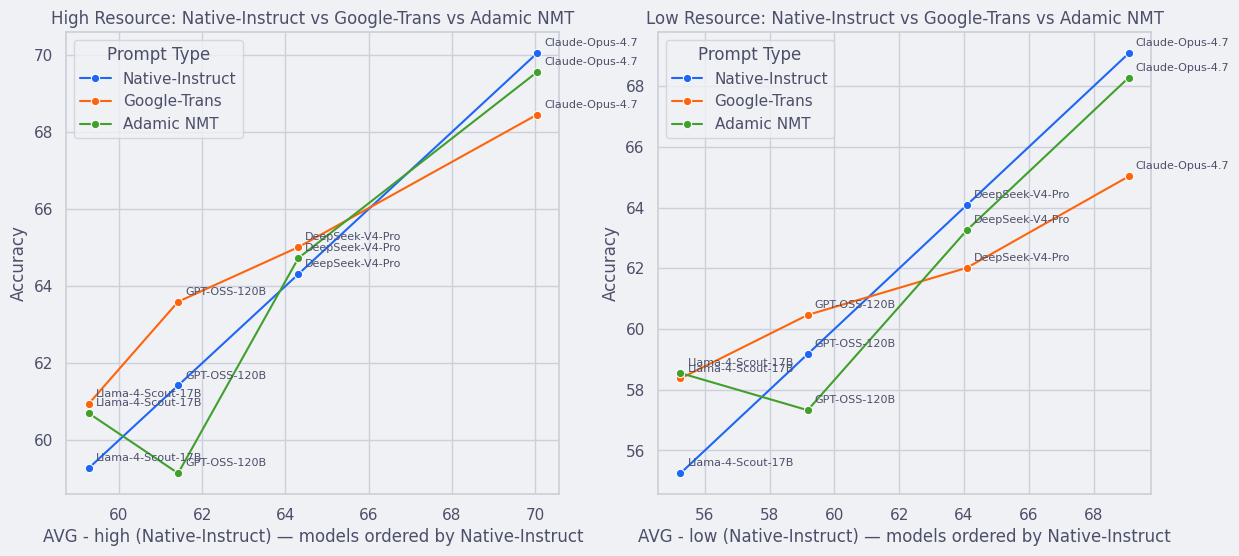

In [131]:
# For each model, plot points where x = direct accuracy (sorted),
# and y = accuracy of "direct", "google_direct", and "adamic" prompt types.
# Compare for both AVG - high and AVG - low.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in [
    (axes[0], "AVG - high", "High Resource: Native-Instruct vs Google-Trans vs Adamic NMT"),
    (axes[1], "AVG - low", "Low Resource: Native-Instruct vs Google-Trans vs Adamic NMT"),
]:
    # Sort models by their direct score
    direct_scores = (
        df_main[df_main["Prompt Type"] == "Native-Instruct"]
        .set_index("Model")[col]
        .sort_values()
    )
    sorted_models = direct_scores.index.tolist()

    native_scores = df_main[df_main["Prompt Type"] == "Native-Instruct"].set_index("Model")[col]
    google_scores = df_main[df_main["Prompt Type"] == "Google-Trans"].set_index("Model")[col]
    adamic_nmt = df_main[df_main["Prompt Type"] == "Adamic NMT"].set_index("Model")[col]

    plot_df = pd.DataFrame({
        "Model": sorted_models,
        "x (Native-Instruct)": [native_scores[m] for m in sorted_models],
        "Native-Instruct": [native_scores[m] for m in sorted_models],
        "Google-Trans": [google_scores[m] for m in sorted_models],
        "Adamic NMT": [adamic_nmt[m] for m in sorted_models],
    })

    long_df = plot_df.melt(
        id_vars=["Model", "x (Native-Instruct)"],
        value_vars=["Native-Instruct", "Google-Trans", "Adamic NMT"],
        var_name="Prompt Type",
        value_name="Accuracy",
    )

    sns.lineplot(
        data=long_df,
        x="x (Native-Instruct)",
        y="Accuracy",
        hue="Prompt Type",
        marker="o",
        ax=ax,
    )

    # Annotate each point with the model name
    for _, row in long_df.iterrows():
        ax.annotate(
            row["Model"],
            (row["x (Native-Instruct)"], row["Accuracy"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

    ax.set_title(title)
    ax.set_xlabel(f"{col} (Native-Instruct) — models ordered by Native-Instruct")

In [ ]:
# For each model, plot points where x = direct_native accuracy (sorted),
# and y = accuracy of "direct_native", "google_direct", and "adamic" prompt types.
# Compare for both AVG - high and AVG - L.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in [
    (axes[0], "AVG - high", "High Resource: direct_native vs google_direct vs adamic"),
    (axes[1], "AVG - low", "Low Resource: direct_native vs google_direct vs adamic"),
]:
    # Sort models by their direct_native score
    direct_scores = (
        df_main[df_main["Prompt Type"] == "direct_native"]
        .set_index("Model")[col]
        .sort_values()
    )
    sorted_models = direct_scores.index.tolist()

    native_scores = df_main[df_main["Prompt Type"] == "direct_native"].set_index("Model")[col]
    google_scores = df_main[df_main["Prompt Type"] == "google_direct"].set_index("Model")[col]
    adamic_scores = df_main[df_main["Prompt Type"] == "adamic"].set_index("Model")[col]

    plot_df = pd.DataFrame({
        "Model": sorted_models,
        "x (direct_native score)": [direct_scores[m] for m in sorted_models],
        "direct_native": [native_scores[m] for m in sorted_models],
        "google_direct": [google_scores[m] for m in sorted_models],
        "adamic": [adamic_scores[m] for m in sorted_models],
    })

    long_df = plot_df.melt(
        id_vars=["Model", "x (direct_native score)"],
        value_vars=["direct_native", "google_direct", "adamic"],
        var_name="Prompt Type",
        value_name="Accuracy",
    )

    sns.lineplot(
        data=long_df,
        x="x (direct_native score)",
        y="Accuracy",
        hue="Prompt Type",
        marker="o",
        ax=ax,
    )

    # Annotate each point with the model name
    for _, row in long_df.iterrows():
        ax.annotate(
            row["Model"],
            (row["x (direct_native score)"], row["Accuracy"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

    ax.set_title(title)
    ax.set_xlabel(f"{col} (direct_native prompt) — models ordered by direct_native")
    ax.set_ylabel(f"{col} (Accuracy)")

plt.tight_layout()
plt.show()